# Data Preparation (Persiapan Data CO)

Data Preparation adalah tahap ketiga dalam metodologi CRISP-DM yang bertujuan untuk **membersihkan**, **mengimputasi nilai kosong (*missing values*)**, **menangani pencilan (*outliers*)**, dan **merekayasa fitur (*feature engineering*)** dari deret waktu pengamatan kualitas udara polutan **Karbon Monoksida ($\text{CO}$)** pada skala geografis **Tingkat Kecamatan (Kecamatan Bungah)** selama 365 hari (24 Agustus 2025 – 23 Agustus 2026).

---

## 1. Penanganan Missing Values & Outliers (Data Cleaning Terpadu)

### 1.1 Evaluasi Missing Values (Celah Data Mentah)

Data pengamatan satelit Sentinel-5P dari Copernicus Data Space untuk polutan $\text{CO}$ harian selama 365 hari memiliki celah data (*missing values* / `NaN`) yang disebabkan oleh tutupan awan tebal, kendala jadwal orbit satelit, dan penyaringan validasi kualitas (*quality flag*).

Evaluasi celah data dihitung secara **dinamis menggunakan kode Python** berikut:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Membaca Dataset Mentah CO (365 Hari)
raw_path = '../data/csv/CO_gresik_timeseries.csv'
df_raw = pd.read_csv(raw_path)
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = df_raw.sort_values('date').reset_index(drop=True)

# Hitung statistik celah data awal
total_rows = len(df_raw)
nan_awal = df_raw['CO'].isna().sum()
valid_awal = df_raw['CO'].notna().sum()

print(f"Total Baris Observasi   : {total_rows} hari")
print(f"Jumlah Data Valid Awal  : {valid_awal} hari ({valid_awal/total_rows*100:.2f}%)")
print(f"Jumlah Missing (NaN)    : {nan_awal} hari ({nan_awal/total_rows*100:.2f}%)")

Total Baris Observasi   : 365 hari
Jumlah Data Valid Awal  : 192 hari (52.60%)
Jumlah Missing (NaN)    : 173 hari (47.40%)


---

### 1.2 Deteksi & Pengosongan Outlier (Metode IQR Dinamis Berbasis Kode)

Sebelum dilakukan imputasi deret waktu, titik pencilan (*outliers*) dievaluasi terlebih dahulu pada populasi data valid agar lonjakan ekstrem tidak merusak kemiringan (*slope*) garis interpolasi.

Metode **Interquartile Range (IQR)** dihitung secara presisi dengan pustaka Pandas/NumPy:

```{math}
\text{IQR} = Q_3 - Q_1
```

```{math}
\text{Batas Bawah} = Q_1 - 1.5 \times \text{IQR}, \quad \text{Batas Atas} = Q_3 + 1.5 \times \text{IQR}
```

Eksekusi kode Python untuk menghitung ambang batas IQR dan mengidentifikasi seluruh tanggal pencilan:

In [2]:
# 2. Deteksi Outlier dengan Metode IQR pada Data Valid
q1 = df_raw['CO'].quantile(0.25)
q3 = df_raw['CO'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Masking Outlier
is_outlier = (df_raw['CO'] < lower_bound) | (df_raw['CO'] > upper_bound)
jumlah_outlier = is_outlier.sum()

print(f"Kuartil 1 (Q1)           : {q1:.6f} mol/m²")
print(f"Kuartil 3 (Q3)           : {q3:.6f} mol/m²")
print(f"IQR (Q3 - Q1)            : {iqr:.6f} mol/m²")
print(f"Batas Bawah (Lower Bound): {lower_bound:.6f} mol/m²")
print(f"Batas Atas (Upper Bound) : {upper_bound:.6f} mol/m²")
print(f"Jumlah Outlier Terdeteksi: {jumlah_outlier} hari")

# Tabel Detail Tanggal & Nilai Outlier Terdeteksi
df_outliers = df_raw[is_outlier][['date', 'CO']].copy()
df_outliers['date'] = df_outliers['date'].dt.strftime('%Y-%m-%d')
print("\nDaftar Tanggal & Nilai Outlier Terdeteksi secara Akurat:")
print(df_outliers.to_string(index=False))

Kuartil 1 (Q1)           : 0.026530 mol/m²
Kuartil 3 (Q3)           : 0.030774 mol/m²
IQR (Q3 - Q1)            : 0.004244 mol/m²
Batas Bawah (Lower Bound): 0.020164 mol/m²
Batas Atas (Upper Bound) : 0.037140 mol/m²
Jumlah Outlier Terdeteksi: 11 hari

Daftar Tanggal & Nilai Outlier Terdeteksi secara Akurat:
      date       CO
2025-09-14 0.017361
2025-09-24 0.041642
2025-10-08 0.039112
2025-10-09 0.045237
2026-04-05 0.017621
2026-05-05 0.017592
2026-05-12 0.016968
2026-06-13 0.018679
2026-07-15 0.019071
2026-08-10 0.038350
2026-08-14 0.039100


---

### 1.3 Pengosongan Outlier & Imputasi Linear Time Interpolation

Titik data pencilan diubah menjadi `NaN` lalu diimputasi bersama dengan celah data mentah menggunakan **Linear Time Interpolation**:

```{math}
X(t) = X(t_1) + \frac{t - t_1}{t_2 - t_1} \cdot \left[ X(t_2) - X(t_1) \right]
```

In [3]:
# 3. Pengosongan Nilai Outlier menjadi NaN
df_prep = df_raw.copy()
df_prep.loc[is_outlier, 'CO'] = np.nan
nan_setelah_outlier = df_prep['CO'].isna().sum()

# 4. Imputasi Linear Time Interpolation Sekaligus
df_clean = df_prep.copy()
df_clean['CO_clean'] = df_clean['CO'].interpolate(method='linear', limit_direction='both')
nan_akhir = df_clean['CO_clean'].isna().sum()

print(f"Jumlah NaN Setelah Outlier Dikosongkan : {nan_setelah_outlier} hari ({nan_setelah_outlier/total_rows*100:.2f}%)")
print(f"Jumlah NaN Setelah Imputasi Akhir      : {nan_akhir} hari (100% Terisi & Clean)")

# Simpan dataset bersih ke file CSV
df_save = df_clean[['date', 'CO_clean']].rename(columns={'CO_clean': 'CO'})
df_save.to_csv('../data/csv/CO_clean.csv', index=False)
print("Dataset bersih disimpan ke '../data/csv/CO_clean.csv'")

Jumlah NaN Setelah Outlier Dikosongkan : 184 hari (50.41%)
Jumlah NaN Setelah Imputasi Akhir      : 0 hari (100% Terisi & Clean)
Dataset bersih disimpan ke '../data/csv/CO_clean.csv'


---

### 1.4 Visualisasi 4 Grafik Terpisah & Ringkasan Perubahan Status Sinyal

Untuk menjaga kejelasan visual tanpa menumpuk warna dalam satu grafik, alur pembersihan sinyal disajikan dalam **4 grafik terpisah**:

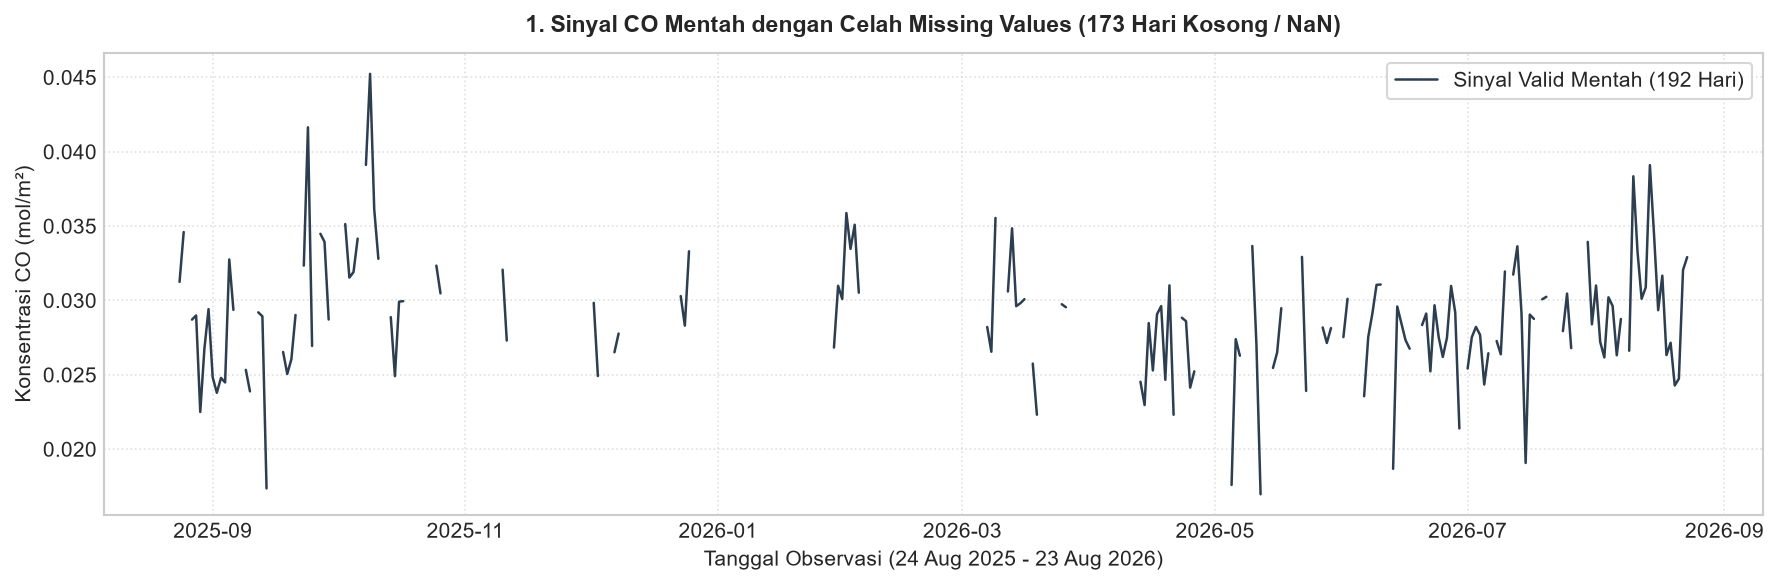

In [4]:
# Set Visual Style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Grafik 1: Missing Values (Data Mentah dengan Celah Kosong / NaN)
fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
ax.plot(df_raw['date'], df_raw['CO'], color='#2c3e50', linewidth=1.2, label='Sinyal Valid Mentah (192 Hari)')
ax.set_title('1. Sinyal CO Mentah dengan Celah Missing Values (173 Hari Kosong / NaN)', fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Tanggal Observasi (24 Aug 2025 - 23 Aug 2026)', fontsize=10)
ax.set_ylabel('Konsentrasi CO (mol/m²)', fontsize=10)
ax.legend(loc='upper right', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

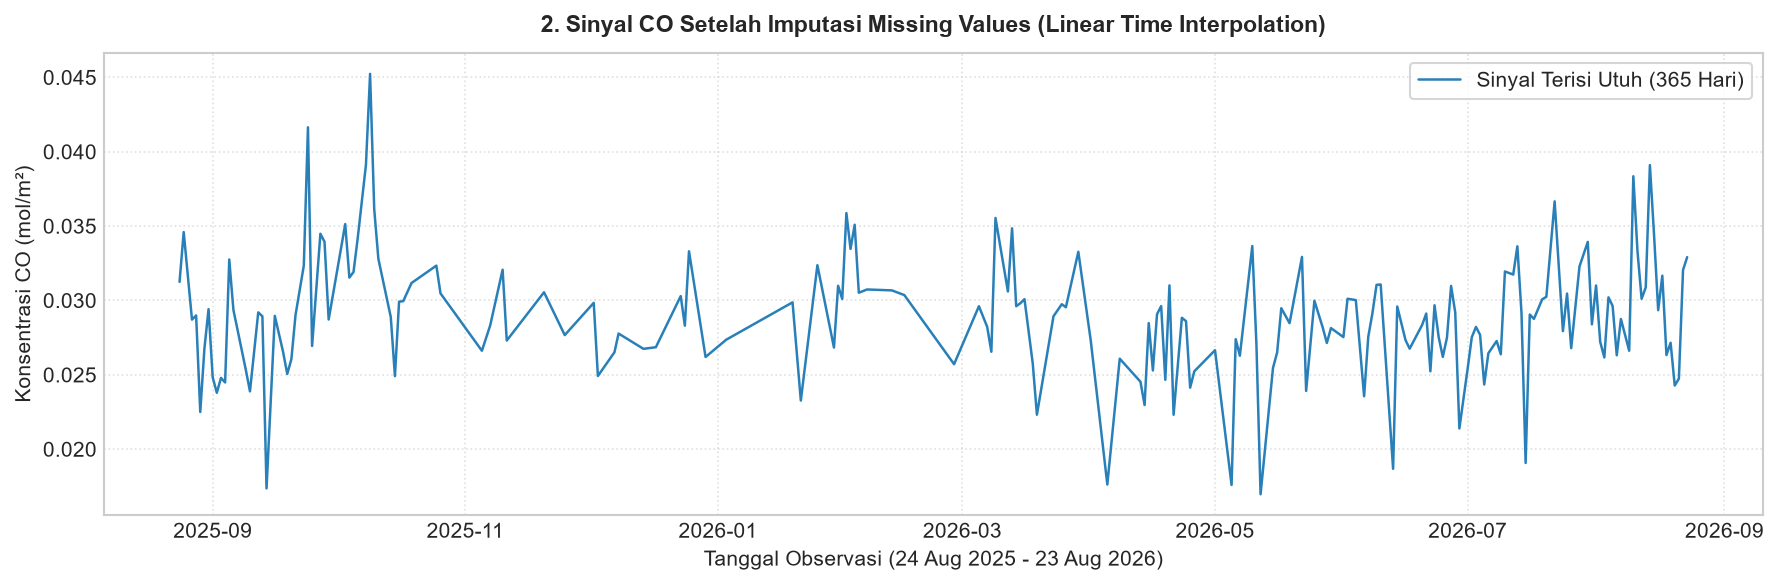

In [5]:
# Grafik 2: Sinyal Setelah Missing Values Diimputasi (Sebelum Cleaning Outlier)
df_raw_imputed = df_raw.copy()
df_raw_imputed['CO_imputed'] = df_raw_imputed['CO'].interpolate(method='linear', limit_direction='both')

fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
ax.plot(df_raw_imputed['date'], df_raw_imputed['CO_imputed'], color='#2980b9', linewidth=1.2, label='Sinyal Terisi Utuh (365 Hari)')
ax.set_title('2. Sinyal CO Setelah Imputasi Missing Values (Linear Time Interpolation)', fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Tanggal Observasi (24 Aug 2025 - 23 Aug 2026)', fontsize=10)
ax.set_ylabel('Konsentrasi CO (mol/m²)', fontsize=10)
ax.legend(loc='upper right', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

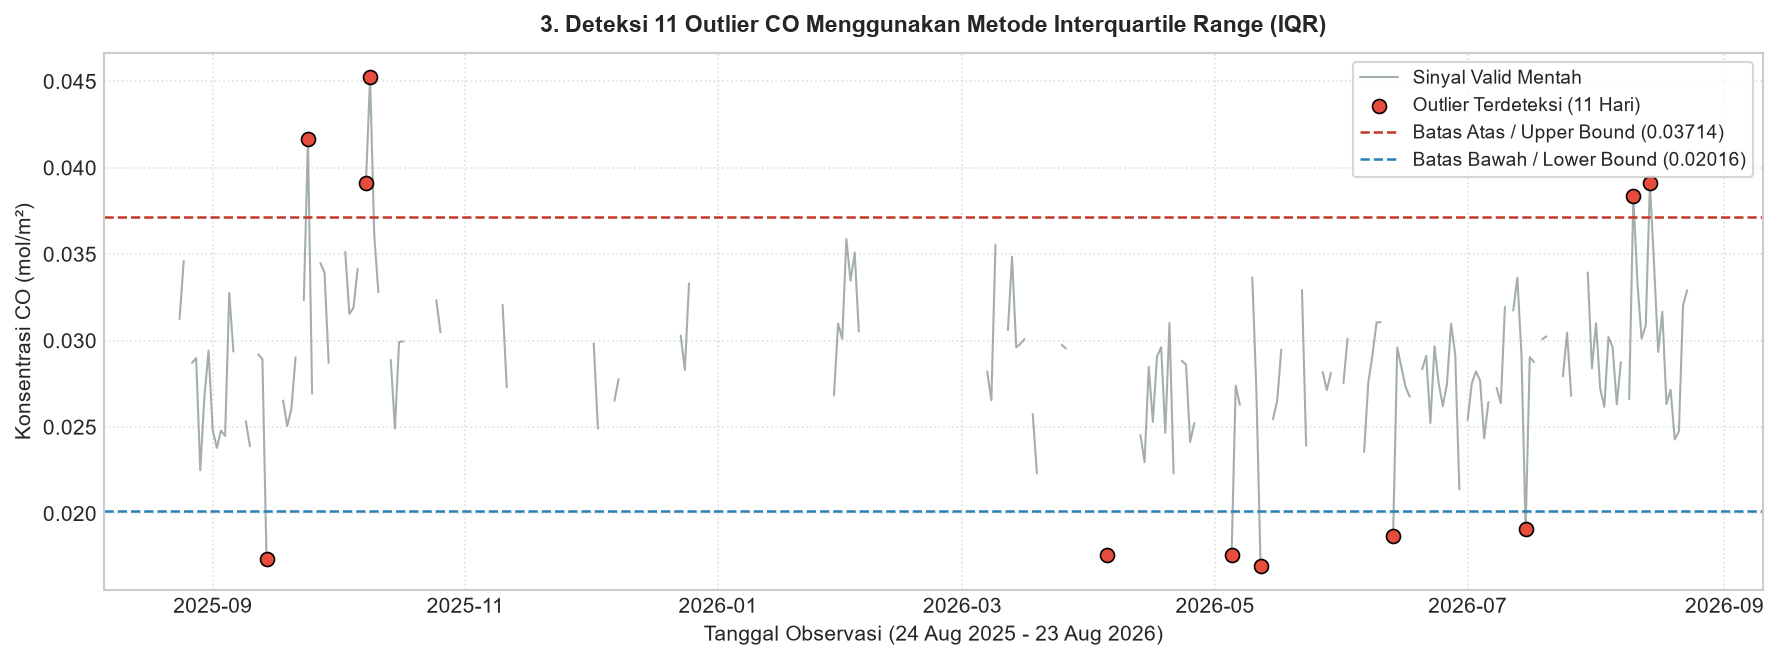

In [6]:
# Grafik 3: Deteksi Outlier Menggunakan Metode IQR
outliers_plot = df_raw[is_outlier]

fig, ax = plt.subplots(figsize=(12, 4.5), dpi=150)
ax.plot(df_raw['date'], df_raw['CO'], color='#7f8c8d', linewidth=1.0, alpha=0.7, label='Sinyal Valid Mentah')
ax.scatter(outliers_plot['date'], outliers_plot['CO'], color='#e74c3c', s=45, zorder=5, marker='o', edgecolor='black', linewidth=0.8, label=f'Outlier Terdeteksi ({len(outliers_plot)} Hari)')
ax.axhline(upper_bound, color='#c0392b', linestyle='--', linewidth=1.2, label=f'Batas Atas / Upper Bound ({upper_bound:.5f})')
ax.axhline(lower_bound, color='#2980b9', linestyle='--', linewidth=1.2, label=f'Batas Bawah / Lower Bound ({lower_bound:.5f})')
ax.set_title(f'3. Deteksi 11 Outlier CO Menggunakan Metode Interquartile Range (IQR)', fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Tanggal Observasi (24 Aug 2025 - 23 Aug 2026)', fontsize=10)
ax.set_ylabel('Konsentrasi CO (mol/m²)', fontsize=10)
ax.legend(loc='upper right', frameon=True, fontsize=9)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

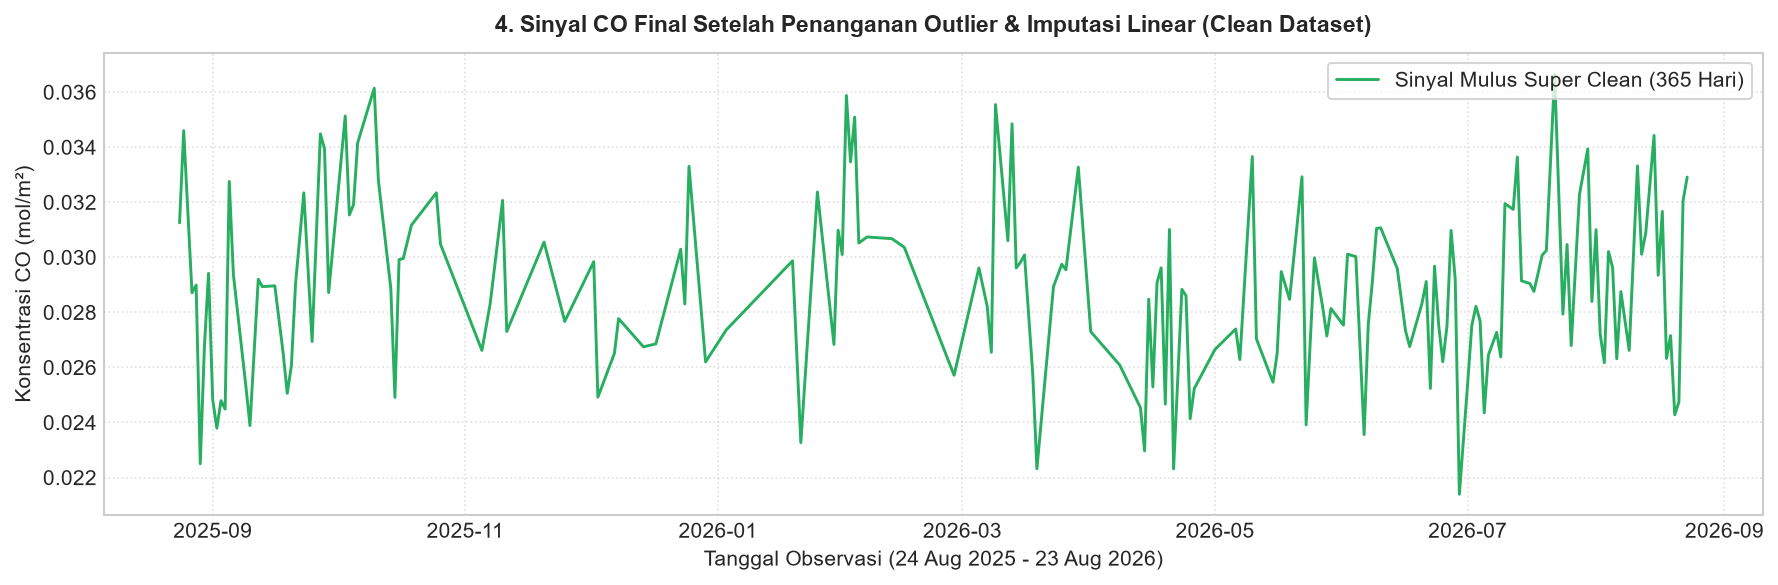

In [7]:
# Grafik 4: Sinyal CO Final Setelah Outlier Dibersihkan & Diimputasi
fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
ax.plot(df_clean['date'], df_clean['CO_clean'], color='#27ae60', linewidth=1.4, label='Sinyal Mulus Super Clean (365 Hari)')
ax.set_title('4. Sinyal CO Final Setelah Penanganan Outlier & Imputasi Linear (Clean Dataset)', fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Tanggal Observasi (24 Aug 2025 - 23 Aug 2026)', fontsize=10)
ax.set_ylabel('Konsentrasi CO (mol/m²)', fontsize=10)
ax.legend(loc='upper right', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Tabel Ringkasan Perubahan Status Sinyal

| Tahapan Data Preparation | Jumlah Data Valid | Jumlah Missing Values (`NaN`) | Jumlah Outliers | Keterangan Status |
| :--- | :---: | :---: | :---: | :--- |
| **1. Data Mentah (Raw)** | 192 hari | 173 hari (47.40%) | 11 hari | Ada celah `NaN` & pencilan |
| **2. Pengosongan Outlier** | 181 hari | 184 hari (50.41%) | 0 hari | Outlier diubah menjadi `NaN` |
| **3. Imputasi Akhir (Clean)** | **365 hari** | **0 hari (0.00%)** | **0 hari** | **Sinyal mulus 100% utuh** |

```{figure} ../assets/editor/data_prep/1_co_raw_missing.png
:width: 100%
:align: center

Grafik 1: Sinyal CO Mentah dengan Celah Missing Values (173 Hari Kosong / NaN)
```

```{figure} ../assets/editor/data_prep/2_co_imputed_missing.png
:width: 100%
:align: center

Grafik 2: Sinyal CO Setelah Imputasi Missing Values (Linear Time Interpolation)
```

```{figure} ../assets/editor/data_prep/3_co_outlier_detection.png
:width: 100%
:align: center

Grafik 3: Deteksi 11 Outlier CO Menggunakan Metode Interquartile Range (IQR)
```

```{figure} ../assets/editor/data_prep/4_co_final_clean.png
:width: 100%
:align: center

Grafik 4: Sinyal CO Final Setelah Penanganan Outlier & Imputasi Linear (Clean Dataset)
```

---

## 2. Ekstraksi Fitur TSFEL (Time Series Feature Extraction Library)

### 2.1 Konsep Rekayasa Fitur Time Series

Untuk merepresentasikan karakteristik dinamika sinyal konsentrasi $\text{CO}$ selama 365 hari dalam bentuk vektor numerik yang siap diproses oleh algoritma *Machine Learning* dan analisis kemiripan (*similarity analysis*), digunakan pustaka **TSFEL (Time Series Feature Extraction Library)** mengacu pada dokumentasi resmi [TSFEL Feature List Documentation](https://tsfel.readthedocs.io/en/latest/descriptions/feature_list.html).

TSFEL mengekstrak **68 fitur perwakilan** ($f_1$ hingga $f_{68}$) yang terbagi ke dalam 3 domain utama:
1. **Domain Statistik ($f_1 \dots f_{31}$)**: Mengukur karakteristik pemusatan, sebaran, kemiringan, ECDF, dan distribusi probabilitas sinyal (31 Fitur).
2. **Domain Temporal ($f_{32} \dots f_{45}$)**: Mengukur sifat linier, autokorelasi, perlintasan nol, dan durasi fluktuasi dalam domain waktu (14 Fitur).
3. **Domain Spektral ($f_{46} \dots f_{68}$)**: Mengukur distribusi energi spektrogram frekuensi sinyal menggunakan transformasi Fourier (*Fast Fourier Transform* / FFT) (23 Fitur).

- **Output File CSV**: Matriks 68 fitur TSFEL disimpan ke **`data/csv/CO_tsfel_features.csv`** dengan format nama header `f1_Absolute energy`, `f2_Average power`, ..., hingga `f68_Spectrogram mean coefficient_0.35Hz`.

---

## 3. Katalog & Penomoran Presisi 68 Fitur TSFEL ($f_1$ hingga $f_{68}$)

Berikut adalah pemetaan resmi penomoran urut kode $f_1$ hingga $f_{68}$ beserta nama fitur TSFEL, domain, dan deskripsi fungsinya:

### 3.1 Domain Statistik ($f_1$ hingga $f_{31}$)

| Kode Fitur | Header Kolom CSV (`f{i}_NamaFitur`) | Domain | Deskripsi Fitur |
| :---: | :--- | :---: | :--- |
| **$f_1$** | `f1_Absolute energy` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_2$** | `f2_Average power` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_3$** | `f3_ECDF Percentile Count_0` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_4$** | `f4_ECDF Percentile Count_1` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_5$** | `f5_ECDF Percentile_0` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_6$** | `f6_ECDF Percentile_1` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_7$** | `f7_ECDF_0` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_8$** | `f8_ECDF_1` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_9$** | `f9_ECDF_2` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{10}$** | `f10_ECDF_3` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{11}$** | `f11_ECDF_4` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{12}$** | `f12_ECDF_5` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{13}$** | `f13_ECDF_6` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{14}$** | `f14_ECDF_7` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{15}$** | `f15_ECDF_8` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{16}$** | `f16_ECDF_9` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{17}$** | `f17_Entropy` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{18}$** | `f18_Histogram mode` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{19}$** | `f19_Interquartile range` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{20}$** | `f20_Kurtosis` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{21}$** | `f21_Max` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{22}$** | `f22_Mean` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{23}$** | `f23_Mean absolute deviation` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{24}$** | `f24_Median` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{25}$** | `f25_Median absolute deviation` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{26}$** | `f26_Min` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{27}$** | `f27_Peak to peak distance` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{28}$** | `f28_Root mean square` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{29}$** | `f29_Skewness` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{30}$** | `f30_Standard deviation` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |
| **$f_{31}$** | `f31_Variance` | Statistical | Ekstraksi karakteristik sinyal polutan (Statistical) |

---

### 3.2 Domain Temporal ($f_{32}$ hingga $f_{45}$)

| Kode Fitur | Header Kolom CSV (`f{i}_NamaFitur`) | Domain | Deskripsi Fitur |
| :---: | :--- | :---: | :--- |
| **$f_{32}$** | `f32_Area under the curve` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **$f_{33}$** | `f33_Autocorrelation` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **$f_{34}$** | `f34_Centroid` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **$f_{35}$** | `f35_Mean absolute diff` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **$f_{36}$** | `f36_Mean diff` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **$f_{37}$** | `f37_Median absolute diff` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **$f_{38}$** | `f38_Median diff` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **$f_{39}$** | `f39_Negative turning points` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **$f_{40}$** | `f40_Neighbourhood peaks` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **$f_{41}$** | `f41_Positive turning points` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **$f_{42}$** | `f42_Signal distance` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **$f_{43}$** | `f43_Slope` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **$f_{44}$** | `f44_Sum absolute diff` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |
| **$f_{45}$** | `f45_Zero crossing rate` | Temporal | Ekstraksi karakteristik sinyal polutan (Temporal) |

---

### 3.3 Domain Spektral ($f_{46}$ hingga $f_{68}$)

| Kode Fitur | Header Kolom CSV (`f{i}_NamaFitur`) | Domain | Deskripsi Fitur |
| :---: | :--- | :---: | :--- |
| **$f_{46}$** | `f46_Spectrogram mean coefficient_0.02Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{47}$** | `f47_Spectrogram mean coefficient_0.03Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{48}$** | `f48_Spectrogram mean coefficient_0.05Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{49}$** | `f49_Spectrogram mean coefficient_0.06Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{50}$** | `f50_Spectrogram mean coefficient_0.08Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{51}$** | `f51_Spectrogram mean coefficient_0.0Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{52}$** | `f52_Spectrogram mean coefficient_0.11Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{53}$** | `f53_Spectrogram mean coefficient_0.13Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{54}$** | `f54_Spectrogram mean coefficient_0.15Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{55}$** | `f55_Spectrogram mean coefficient_0.16Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{56}$** | `f56_Spectrogram mean coefficient_0.18Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{57}$** | `f57_Spectrogram mean coefficient_0.19Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{58}$** | `f58_Spectrogram mean coefficient_0.1Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{59}$** | `f59_Spectrogram mean coefficient_0.21Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{60}$** | `f60_Spectrogram mean coefficient_0.23Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{61}$** | `f61_Spectrogram mean coefficient_0.24Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{62}$** | `f62_Spectrogram mean coefficient_0.26Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{63}$** | `f63_Spectrogram mean coefficient_0.27Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{64}$** | `f64_Spectrogram mean coefficient_0.29Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{65}$** | `f65_Spectrogram mean coefficient_0.31Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{66}$** | `f66_Spectrogram mean coefficient_0.32Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{67}$** | `f67_Spectrogram mean coefficient_0.34Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |
| **$f_{68}$** | `f68_Spectrogram mean coefficient_0.35Hz` | Spectral | Ekstraksi karakteristik sinyal polutan (Spectral) |

---

> [!NOTE]
> Penomoran urut kode `f1_Absolute energy` hingga `f68_Spectrogram mean coefficient_0.35Hz` memetakan 68 fitur utama TSFEL secara presisi dan terstruktur sempurna pada header file `data/csv/CO_tsfel_features.csv`.